In [10]:
# Include packages and builtin classes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [11]:
# Read the csv file to be considered for Multi-classification

df = pd.read_csv("Iris_data.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
# Preporcessing

print("Before : ")
print(df.isnull().sum())

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
  df[col] = df[col].fillna(df[col].median())

print("\nAfter : ")
print(df.isnull().sum())

Before : 
sepal_length    0
sepal_width     3
petal_length    3
petal_width     0
species         0
dtype: int64

After : 
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [16]:
# Seperate the input features and target from the dataset

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.head())
print("\nClasses:\n")
print(y.unique())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Classes:

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [19]:
 #Transform the categorial into numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print("Encoded Classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Encoded Classes:
{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [20]:
# Split the data  for training  and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(" X_train shape : ", X_train.shape)
print(" X_test  shape : ", X_test.shape)

 X_train shape :  (120, 4)
 X_test  shape :  (30, 4)


In [21]:
# Normalize the input features - Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[-1.47393679  1.22457616 -1.56499059 -1.30948358]
 [-0.13307079  3.0248719  -1.27686713 -1.04292204]
 [ 1.08589829  0.09939133  0.39424893  0.28988568]
 [-1.23014297  0.77450223 -1.21924244 -1.30948358]
 [-1.7177306   0.32442829 -1.39211651 -1.30948358]]


In [23]:
# Define the MLP classifier

mlp = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation='relu',
    max_iter=1000,
    random_state=42
  )

In [24]:
# Train the classifier

mlp.fit(X_train, y_train)
print("Training Completed")

Training Completed


In [31]:
#  Evaluation of algorithm performance in classifying.

y_pred = mlp.predict(X_test)
print("Predicted Output : ",y_pred)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy =", accuracy * 100,"%")

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix : \n",cm)

report = classification_report(
    y_test,
    y_pred
)

print("\n\nClassification Report :\n",report)

Predicted Output :  [1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy = 96.66666666666667 %

Confusion Matrix : 
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



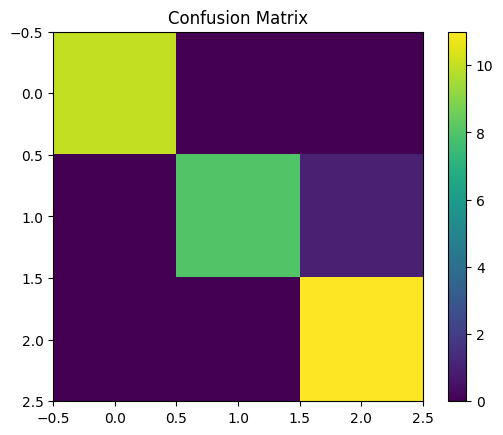

In [33]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()